

## Graph Search problem in with polygonal objects in space

sample space:   

![alt text](image.png)

state: 

A state is defined as the current vertex where the agent is located. Each vertex is represented by its coordinates (x,y)(x, y)(x,y).

initial state: The predefined start point s, which may or may not coincide with a polygon vertex.

goal test: The agent is at the predefined goal point g.

Actions:

ACTIONS(v) returns a set of possible moves from vertex vvv:
- All vertices that are visible from v. this is straight-line connection without intersecting any polygons.
- Adjacent vertices on the same polygon.

transition model: Moving from vertex v to vertex u results in a new state at u.

step cost:
- cost(v,u)=sqrt((xv−xu)^2+(yv−yu))
- euclidean distance

heuristic function:
- Straight-line distance from current vertex to goal
- admissible because it never overestimates the true cost
- h(v)=sqrt((xv−xg)^2+(yv−yg)2^)

path cost: Sum of Euclidean distances along the path.

State Space:
- Nodes: All polygon vertices + start + goal.
- Edges: Visibility connections (including polygon adjacency)
- Size (If there are m vertices total):
    - Nodes = m+2
    - Edges = up to O(m2) in worst case.

## Implementation: Polygon Obstacle Navigation

### Imports

In [1]:
# Import required modules
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().resolve().parent.parent))

from search4e import Problem
import numpy as np
from utils import distance

### Helpers

- `cross_product_2d(o, a, b)` — 2D cross product (z); >0 ccw, <0 cw, 0 collinear.  
- `on_segment(p, q, r)` — True if `q` lies on segment `pr` (assumes collinear).  
- `segments_intersect(p1, q1, p2, q2)` — Orientation-based segment intersection test (includes endpoint touching).  
- `line_intersects_polygon(p1, p2, polygon_coords)` — True if segment `p1-p2` intersects any polygon edge (allows edge traversal).  
- `is_visible(p1, p2, obstacles)` — Line-of-sight test across all polygons (uses `line_intersects_polygon`).  
- `get_polygon_neighbors(vertex, obstacles)` — Returns adjacent vertices on the same polygon (previous, next) if `vertex` is a polygon vertex.  
- `get_all_vertices(obstacles, start, goal)` — Returns unique list of all polygon vertices plus `start` and `goal`.



In [2]:
# Geometric Helper Functions

def cross_product_2d(o, a, b):
    """
    Calculate the 2D cross product (z-component) of vectors OA and OB.
    Used for orientation test.
    Returns: positive if counter-clockwise, negative if clockwise, 0 if collinear
    """
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def on_segment(p, q, r):
    """
    Check if point q lies on line segment pr (given that p, q, r are collinear).
    """
    return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
            q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))


def segments_intersect(p1, q1, p2, q2):
    """
    Check if line segment p1q1 and p2q2 intersect.
    Uses orientation-based algorithm.
    
    Args:
        p1, q1: endpoints of first segment
        p2, q2: endpoints of second segment
    
    Returns:
        True if segments intersect (including endpoints touching)
    """
    # Find the four orientations needed for general and special cases
    o1 = cross_product_2d(p1, q1, p2)
    o2 = cross_product_2d(p1, q1, q2)
    o3 = cross_product_2d(p2, q2, p1)
    o4 = cross_product_2d(p2, q2, q1)
    
    # General case: segments intersect if they have different orientations
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True
    
    # Special cases: check if points are collinear and one lies on the other segment
    if o1 == 0 and on_segment(p1, p2, q1):
        return True
    if o2 == 0 and on_segment(p1, q2, q1):
        return True
    if o3 == 0 and on_segment(p2, p1, q2):
        return True
    if o4 == 0 and on_segment(p2, q1, q2):
        return True
    
    return False


def line_intersects_polygon(p1, p2, polygon_coords):
    """
    Check if line segment from p1 to p2 intersects any edge of the polygon.
    
    Args:
        p1, p2: endpoints of the line segment (tuples)
        polygon_coords: list of (x, y) tuples representing polygon vertices
    
    Returns:
        True if line intersects polygon interior
    """
    n = len(polygon_coords)
    
    # Check if both p1 and p2 are vertices of this polygon
    p1_idx = polygon_coords.index(p1) if p1 in polygon_coords else -1
    p2_idx = polygon_coords.index(p2) if p2 in polygon_coords else -1
    
    # If both points are on this polygon, check if they're adjacent
    if p1_idx >= 0 and p2_idx >= 0:
        # Calculate distance along the polygon
        dist = abs(p1_idx - p2_idx)
        # Adjacent if distance is 1 or n-1 (wrapping around)
        is_adjacent = (dist == 1) or (dist == n - 1)
        
        if is_adjacent:
            # Adjacent vertices - line is along the edge, no intersection
            return False
        else:
            # Non-adjacent vertices on same polygon - line goes through interior
            return True
    
    # Check each edge for intersection
    for i in range(n):
        edge_start = polygon_coords[i]
        edge_end = polygon_coords[(i + 1) % n]
        
        # Allow movement along polygon edges
        if ((p1 == edge_start and p2 == edge_end) or 
            (p1 == edge_end and p2 == edge_start)):
            continue
        
        # Skip edges where p1 or p2 is an endpoint (allows touching corners from outside)
        if p1 == edge_start or p1 == edge_end or p2 == edge_start or p2 == edge_end:
            continue
        
        # Check if line intersects this edge
        if segments_intersect(p1, p2, edge_start, edge_end):
            return True
    
    return False


def is_visible(p1, p2, obstacles):
    """
    Check if two points are mutually visible (no polygon blocking the line of sight).
    
    Args:
        p1, p2: points to check (tuples)
        obstacles: list of polygons, where each polygon is a list of (x, y) coordinates
    
    Returns:
        True if p1 and p2 are visible to each other
    """
    # Check against all obstacle polygons
    for polygon in obstacles:
        if line_intersects_polygon(p1, p2, polygon):
            return False
    return True


def get_polygon_neighbors(vertex, obstacles):
    """
    Get adjacent vertices on the same polygon.
    
    Args:
        vertex: (x, y) tuple
        obstacles: list of polygons
    
    Returns:
        List of adjacent vertices (previous and next on same polygon)
    """
    for polygon in obstacles:
        if vertex in polygon:
            idx = polygon.index(vertex)
            n = len(polygon)
            
            # Return the two adjacent vertices
            prev_vertex = polygon[(idx - 1) % n]
            next_vertex = polygon[(idx + 1) % n]
            
            return [prev_vertex, next_vertex]
    
    return []


def get_all_vertices(obstacles, start, goal):
    """
    Extract all unique vertices from obstacles plus start and goal points.
    
    Args:
        obstacles: list of polygons
        start: start point (x, y)
        goal: goal point (x, y)
    
    Returns:
        List of all unique vertices
    """
    vertices = [start, goal]
    
    for polygon in obstacles:
        for vertex in polygon:  # tuple (x, y)
            if vertex not in vertices:
                vertices.append(vertex)
    
    return vertices


### Polygon Navigation Problem

- Purpose: Problem subclass for navigation in a 2D world with polygonal obstacles using on‑demand visibility.
- Key attributes: initial, goal, obstacles, all_vertices (start+goal+unique polygon vertices).
- State: (x, y) coordinate tuple (current position).
- `actions(state)`: all vertices visible from state plus adjacent polygon vertices.
- `result(state, action)`: returns destination vertex (action).
- `path_cost(c, s1, a, s2)`: c + Euclidean distance(s1, s2).
- `h(node)`: straight‑line (Euclidean) distance to goal — admissible.

Notes: visibility computed via helpers (is_visible, line_intersects_polygon); adjacency via get_polygon_neighbors.

In [3]:
# Polygon Obstacle Navigation Problem Class

class PolygonObstacleNavigation(Problem):
    """
    Navigation problem with polygonal obstacles.
    Uses on-demand visibility computation - calculates visible vertices each time actions() is called.
    
    Follows search4e.ipynb coding standards with is_goal() and action_cost() method names.
    
    State: (x, y) coordinate tuple representing current position
    Actions: Move to any visible vertex
    """
    
    def __init__(self, initial, goal, obstacles):
        """
        Args:
            initial: (x, y) tuple for start position
            goal: (x, y) tuple for goal position
            obstacles: list of polygons, each polygon is a list of (x, y) tuples
        """
        super().__init__(initial, goal)
        self.obstacles = obstacles
        # Extract all vertices for reference
        self.all_vertices = get_all_vertices(obstacles, initial, goal)
    
    def actions(self, state):
        """
        Return all vertices visible from the current state.
        Computes visibility on-demand.
        
        Args:
            state: (x, y) tuple representing current position
        
        Returns:
            List of (x, y) tuples representing reachable vertices
        """
        visible_vertices = []
        
        # Check visibility to all other vertices
        for vertex in self.all_vertices:
            if vertex == state:
                continue  # Skip current position
            
            # Check if vertex is visible i.e. no polygon intersection
            if is_visible(state, vertex, self.obstacles):
                visible_vertices.append(vertex)
        
        # Add adjacent vertices on the same polygon
        polygon_neighbors = get_polygon_neighbors(state, self.obstacles)
        for neighbor in polygon_neighbors:
            if neighbor not in visible_vertices:
                visible_vertices.append(neighbor)
        
        return visible_vertices
    
    def result(self, state, action):
        """
        The result of moving to a vertex is that vertex.
        
        Args:
            state: current position
            action: target vertex (x, y)
        
        Returns:
            The action itself (the destination vertex)
        """
        return action
    
    def action_cost(self, s, a, s1):
        """
        Cost of moving from state s to state s1 via action a.
        Uses Euclidean distance as the cost.
        
        Args:
            s: current state
            a: action taken (target vertex)
            s1: resulting state
        
        Returns:
            Euclidean distance from s to s1
        """
        return distance(s, s1)
    
    def h(self, node):
        """
        Heuristic: straight-line distance to goal (admissible).
        
        Args:
            node: search node
        
        Returns:
            Estimated cost to goal
        """
        return distance(node.state, self.goal)
    
    def is_goal(self, state):
        """
        Check if current state is the goal.
        
        Args:
            state: current position
        
        Returns:
            True if at goal position
        """
        return state == self.goal

### Polygon Problem Instance

In [4]:
# Define test obstacles (simple rectangular obstacles)
obstacles = [
    [(2, 2), (4, 2), (4, 4), (2, 4)],  # Rectangle 1
    [(6, 1), (8, 1), (8, 3), (6, 3)],  # Rectangle 2
    [(5, 5), (7, 5), (7, 7), (5, 7)]   # Rectangle 3
]

# Define start and goal positions
start = (0, 0)
goal = (9, 8)

# Create the problem instance
polygon_problem = PolygonObstacleNavigation(start, goal, obstacles)

print("Problem created successfully!")
print(f"Start: {polygon_problem.initial}")
print(f"Goal: {polygon_problem.goal}")
print(f"Number of obstacles: {len(polygon_problem.obstacles)}")
print(f"Total vertices (including start and goal): {len(polygon_problem.all_vertices)}")

Problem created successfully!
Start: (0, 0)
Goal: (9, 8)
Number of obstacles: 3
Total vertices (including start and goal): 14


### Polygon test case: Simple Rectangle

Create a test scenario with a few polygonal obstacles to verify the implementation.
square world

```text

8  |                                             * G
7  |                        +---------+
6  |                        |  R3     |
5  |                        +---------+
4  |        +----------+
3  |        |  R1      |         +---------+
2  |        +----------+         |  R2     |
1  |                             +---------+
0  * S
   +----+----+----+----+----+----+----+----+----+
   0    1    2    3    4    5    6    7    8    9  

In [5]:
# Test the actions function - what moves are available from start?
available_actions = polygon_problem.actions(start)

print(f"\nFrom start position {start}, visible vertices are:")
for i, vertex in enumerate(available_actions, 1):
    dist = distance(start, vertex)
    print(f"  {i}. {vertex} (distance: {dist:.2f})")


From start position (0, 0), visible vertices are:
  1. (2, 2) (distance: 2.83)
  2. (4, 2) (distance: 4.47)
  3. (2, 4) (distance: 4.47)
  4. (6, 1) (distance: 6.08)
  5. (8, 1) (distance: 8.06)


### Solve with A* Search

Now let's use A* search to find the optimal path from start to goal.

In [6]:
# Import A* search and path reconstruction function
from search4e import astar_search, path_states

# Solve the problem
solution = astar_search(polygon_problem)

if solution:
    print("Solution found!")
    print(f"\nPath from {start} to {goal}:")
    
    # Reconstruct and display the path using path_states function
    path = path_states(solution)
    total_cost = 0
    
    for i, state in enumerate(path):
        if i > 0:
            segment_cost = distance(path[i-1], state)
            total_cost += segment_cost
            print(f"  Step {i}: {path[i-1]} -> {state} (cost: {segment_cost:.2f})")
        else:
            print(f"  Start: {state}")
    
    print(f"\nTotal path cost: {total_cost:.2f}")
    print(f"Number of steps: {len(path) - 1}")
else:
    print("No solution found!")

Solution found!

Path from (0, 0) to (9, 8):
  Start: (0, 0)
  Step 1: (0, 0) -> (4, 2) (cost: 4.47)
  Step 2: (4, 2) -> (7, 5) (cost: 4.24)
  Step 3: (7, 5) -> (9, 8) (cost: 3.61)

Total path cost: 12.32
Number of steps: 3


### Visualization Helper

Function to visualize the problem space and solution path.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from matplotlib.collections import PatchCollection
from search4e import path_states

def visualize_problem(problem, solution=None):
    """
    Visualize the polygon obstacle navigation problem and solution.
    
    Args:
        problem: PolygonObstacleNavigation instance
        solution: solution node from search (optional)
    """
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    
    # Draw obstacles
    patches = []
    for obstacle in problem.obstacles:
        polygon = MPLPolygon(obstacle, closed=True)
        patches.append(polygon)
    
    collection = PatchCollection(patches, facecolors='gray', edgecolors='black', linewidths=1, alpha=1)
    ax.add_collection(collection)
    
    # Draw all vertices
    for vertex in problem.all_vertices:
        if vertex != problem.initial and vertex != problem.goal:
            ax.plot(vertex[0], vertex[1], 'o', color='blue', markersize=4)
    
    # Draw start and goal
    ax.plot(problem.initial[0], problem.initial[1], 'o', color='green', markersize=10, label='Start (S)')
    ax.plot(problem.goal[0], problem.goal[1], '*', color='red', markersize=10, label='Goal (G)')
    
    # Draw solution path if provided
    if solution:
        path = path_states(solution)
        x_coords = [state[0] for state in path]
        y_coords = [state[1] for state in path]
        ax.plot(x_coords, y_coords, 'r-', linewidth=1, alpha=0.7, label='Solution Path')
        ax.plot(x_coords, y_coords, 'ro', markersize=4)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Polygon Obstacle Navigation Problem')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Set axis limits with some padding
    all_x = [v[0] for v in problem.all_vertices]
    all_y = [v[1] for v in problem.all_vertices]
    ax.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax.set_ylim(min(all_y) - 1, max(all_y) + 1)
    
    plt.tight_layout()
    plt.show()

### solution plot

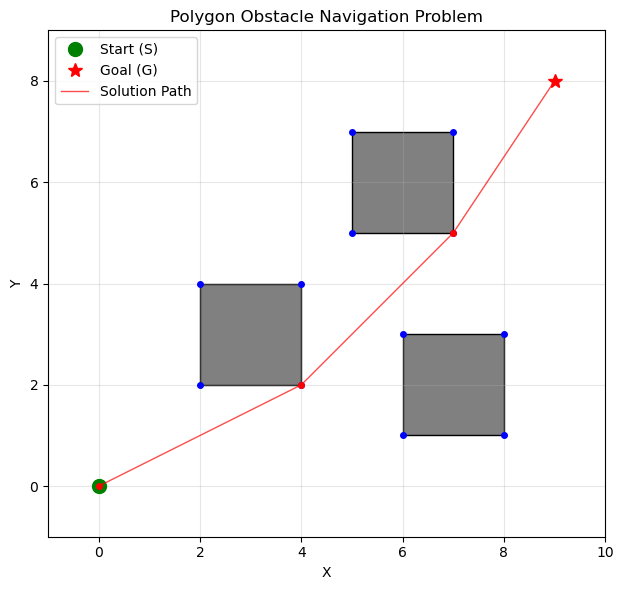

In [8]:
# Visualize the problem with solution
visualize_problem(polygon_problem, solution)

## Comparing Multiple Search Algorithms

Now let's test the polygon navigation problem with various search algorithms from search4e.py to compare their performance and path quality.

### Import Additional Search Algorithms

Import various search algorithms to compare their performance on the polygon navigation problem.

In [9]:
# Import additional search algorithms from search4e
from search4e import (
    uniform_cost_search,
    greedy_bfs,
    weighted_astar_search,
    breadth_first_search,
    breadth_first_bfs,
    depth_first_bfs,
    iterative_deepening_search,
    depth_limited_search,
    CountCalls,
    report,
    path_actions
)

print("Additional search algorithms imported successfully!")

Additional search algorithms imported successfully!


### Test Individual Algorithms

Test various search algorithms individually and compare their solutions.

In [10]:
# Test multiple search algorithms on the polygon problem
algorithms = [
    ("A* Search", astar_search),
    ("Uniform Cost Search", uniform_cost_search),
    ("Greedy Best-First Search", greedy_bfs),
    ("Weighted A* (w=1.4)", lambda p: weighted_astar_search(p, weight=1.4)),
    ("Weighted A* (w=2.0)", lambda p: weighted_astar_search(p, weight=2.0)),
    ("Breadth-First Search", breadth_first_search),
]

print("Testing different search algorithms on polygon navigation problem:\n")
print("=" * 80)

results = {}

for name, algorithm in algorithms:
    print(f"\n{name}:")
    print("-" * 40)
    
    # Solve with this algorithm
    solution = algorithm(polygon_problem)
    
    if solution and solution.path_cost < float('inf'):
        path = path_states(solution)
        actions = path_actions(solution)
        
        print(f"  Solution found!")
        print(f"  Path cost: {solution.path_cost:.2f}")
        print(f"  Number of steps: {len(actions)}")
        print(f"  Path: {' -> '.join(str(s) for s in path)}")
        
        # Store result for later visualization
        results[name] = solution
    else:
        print(f"  No solution found")
        results[name] = None

print("\n" + "=" * 80)

Testing different search algorithms on polygon navigation problem:


A* Search:
----------------------------------------
  Solution found!
  Path cost: 12.32
  Number of steps: 3
  Path: (0, 0) -> (4, 2) -> (7, 5) -> (9, 8)

Uniform Cost Search:
----------------------------------------
  Solution found!
  Path cost: 12.32
  Number of steps: 3
  Path: (0, 0) -> (4, 2) -> (7, 5) -> (9, 8)

Greedy Best-First Search:
----------------------------------------
  Solution found!
  Path cost: 15.13
  Number of steps: 2
  Path: (0, 0) -> (8, 1) -> (9, 8)

Weighted A* (w=1.4):
----------------------------------------
  Solution found!
  Path cost: 12.32
  Number of steps: 3
  Path: (0, 0) -> (4, 2) -> (7, 5) -> (9, 8)

Weighted A* (w=2.0):
----------------------------------------
  Solution found!
  Path cost: 12.32
  Number of steps: 3
  Path: (0, 0) -> (4, 2) -> (7, 5) -> (9, 8)

Breadth-First Search:
----------------------------------------
  Solution found!
  Path cost: 15.13
  Number of step

### Performance Report with CountCalls

Use the `report()` function to get detailed statistics about nodes explored, goal tests, and costs for each algorithm.

In [11]:
# Detailed performance comparison using report()
print("\nDetailed Performance Comparison")
print("=" * 100)
print("Format: nodes_explored | goal_tests | path_cost | num_actions | algorithm_name")
print("=" * 100)

# List of searcher functions
searchers = [
    astar_search,
    uniform_cost_search,
    greedy_bfs,
    lambda p: weighted_astar_search(p, weight=1.4),
    lambda p: weighted_astar_search(p, weight=2.0),
    breadth_first_search,
]

# Give names to lambda functions for better reporting
searchers[3].__name__ = "weighted_astar_1.4"
searchers[4].__name__ = "weighted_astar_2.0"

# Run the report
report(searchers, [polygon_problem], verbose=True)


Detailed Performance Comparison
Format: nodes_explored | goal_tests | path_cost | num_actions | algorithm_name
astar_search:
       25 nodes |        5 goal |   12 cost |       7 actions | PolygonObstacleNavigation((0, 0), (9, 8)
       25 nodes |        5 goal |   12 cost |       7 actions | TOTAL

uniform_cost_search:
       97 nodes |       16 goal |   12 cost |      18 actions | PolygonObstacleNavigation((0, 0), (9, 8)
       97 nodes |       16 goal |   12 cost |      18 actions | TOTAL

greedy_bfs:
        9 nodes |        3 goal |   15 cost |       4 actions | PolygonObstacleNavigation((0, 0), (9, 8)
        9 nodes |        3 goal |   15 cost |       4 actions | TOTAL

weighted_astar_1.4:
       21 nodes |        4 goal |   12 cost |       6 actions | PolygonObstacleNavigation((0, 0), (9, 8)
       21 nodes |        4 goal |   12 cost |       6 actions | TOTAL

weighted_astar_2.0:
       21 nodes |        4 goal |   12 cost |       6 actions | PolygonObstacleNavigation((0, 0),

### Visualize Different Algorithm Solutions

Compare the paths found by different algorithms side-by-side.

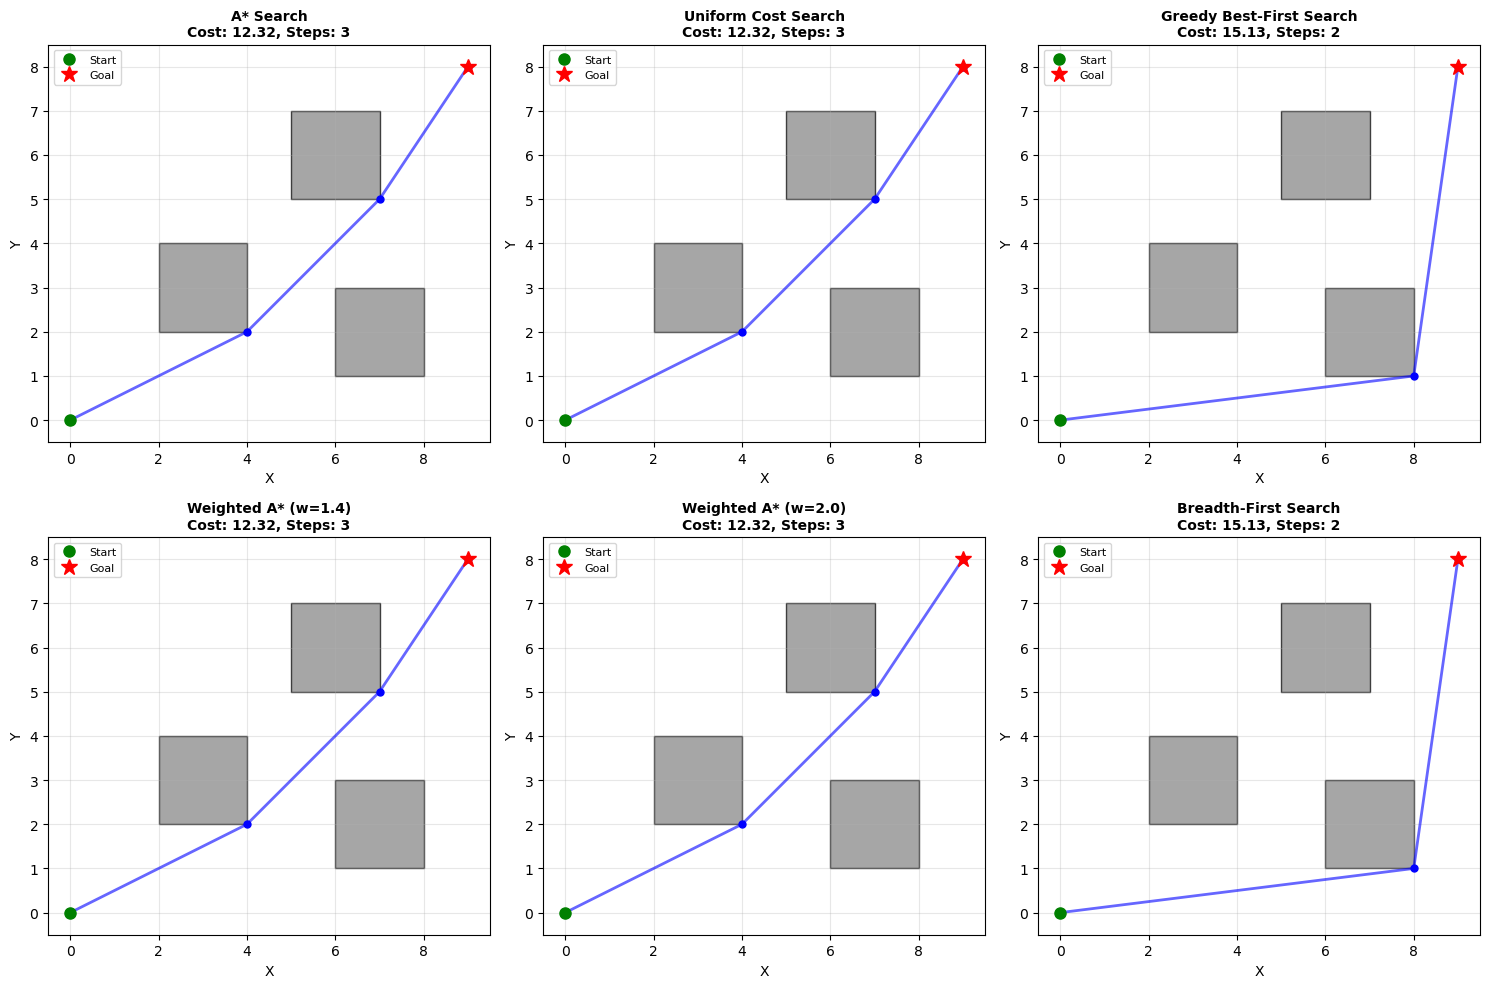

In [12]:
# Visualize solutions from different algorithms in a grid
def visualize_multiple_solutions(problem, solutions_dict, figsize=(15, 10)):
    """
    Visualize multiple algorithm solutions side-by-side.
    
    Args:
        problem: PolygonObstacleNavigation instance
        solutions_dict: dict mapping algorithm names to solution nodes
        figsize: figure size tuple
    """
    n_algorithms = len(solutions_dict)
    n_cols = 3
    n_rows = (n_algorithms + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_algorithms > 1 else [axes]
    
    for idx, (name, solution) in enumerate(solutions_dict.items()):
        ax = axes[idx]
        
        # Draw obstacles
        patches = []
        for obstacle in problem.obstacles:
            polygon = MPLPolygon(obstacle, closed=True)
            patches.append(polygon)
        
        collection = PatchCollection(patches, facecolors='gray', edgecolors='black', 
                                    linewidths=1, alpha=0.7)
        ax.add_collection(collection)
        
        # Draw start and goal
        ax.plot(problem.initial[0], problem.initial[1], 'o', color='green', 
                markersize=8, label='Start', zorder=5)
        ax.plot(problem.goal[0], problem.goal[1], '*', color='red', 
                markersize=12, label='Goal', zorder=5)
        
        # Draw solution path if available
        if solution and solution.path_cost < float('inf'):
            path = path_states(solution)
            x_coords = [state[0] for state in path]
            y_coords = [state[1] for state in path]
            ax.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.6, zorder=3)
            ax.plot(x_coords, y_coords, 'bo', markersize=5, zorder=4)
            
            title = f"{name}\nCost: {solution.path_cost:.2f}, Steps: {len(path)-1}"
        else:
            title = f"{name}\nNo solution"
        
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend(fontsize=8, loc='upper left')
        
        # Set axis limits
        all_x = [v[0] for v in problem.all_vertices]
        all_y = [v[1] for v in problem.all_vertices]
        ax.set_xlim(min(all_x) - 0.5, max(all_x) + 0.5)
        ax.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)
    
    # Hide unused subplots
    for idx in range(n_algorithms, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize the results
visualize_multiple_solutions(polygon_problem, results)

### Summary Analysis

Key observations about algorithm performance on the polygon navigation problem:

In [13]:
# Create a summary comparison table
print("\nAlgorithm Performance Summary")
print("=" * 90)
print(f"{'Algorithm':<30} {'Path Cost':>12} {'Steps':>8} {'Optimal?':>10}")
print("=" * 90)

# Find the optimal cost
optimal_cost = min(sol.path_cost for sol in results.values() if sol and sol.path_cost < float('inf'))

for name, solution in results.items():
    if solution and solution.path_cost < float('inf'):
        path = path_states(solution)
        is_optimal = "Yes" if abs(solution.path_cost - optimal_cost) < 0.01 else "No"
        print(f"{name:<30} {solution.path_cost:>12.2f} {len(path)-1:>8} {is_optimal:>10}")
    else:
        print(f"{name:<30} {'No solution':>12} {'-':>8} {'-':>10}")


Algorithm Performance Summary
Algorithm                         Path Cost    Steps   Optimal?
A* Search                             12.32        3        Yes
Uniform Cost Search                   12.32        3        Yes
Greedy Best-First Search              15.13        2         No
Weighted A* (w=1.4)                   12.32        3        Yes
Weighted A* (w=2.0)                   12.32        3        Yes
Breadth-First Search                  15.13        2         No
